# R21 Covariate Randomise Effects

Inspect the covariate-adjusted randomise results. C3/C4 test the blink or pupil covariate effects after including mean FD as the adjustment covariate. C1/C2 test the adjusted main effects and are compared with the original unadjusted significant results.


## 1. Verify notebook dependencies

Launch this notebook with `bash notebooks/run_covariate_randomise_notebook.sh`. It only needs the tracked covariate randomise summary files, not the large Linux-only dual-regression folders.

In [1]:
from pathlib import Path
import importlib.util

def find_project_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / 'code' / 'check_covariate_randomise_results.py').is_file():
            return candidate
    raise FileNotFoundError('Start Jupyter from the r21-rest repository or one of its subdirectories.')

PROJECT_ROOT = find_project_root()
required_imports = ('matplotlib', 'numpy', 'pandas', 'scipy')
missing = [name for name in required_imports if importlib.util.find_spec(name) is None]
if missing:
    raise RuntimeError('Missing packages: ' + ', '.join(missing) + '. Relaunch with notebooks/run_covariate_randomise_notebook.sh')
print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/tug87422/github/r21-rest


## 2. Load C3/C4 covariate rows

FSL corrected-p images store `1-p`, so `peak_corrp > 0.95` corresponds to corrected `p < 0.05`. This first audit focuses on C3/C4, the covariate-effect tests. C1/C2 main effects are handled in later sections.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from IPython.display import display, Markdown

CORRP_THRESHOLD = 0.95
SUMMARY = PROJECT_ROOT / 'derivatives' / 'fsl' / 'covariate_randomise_summary' / 'task-rest_covariate-randomise_peak_summary.tsv'
if not SUMMARY.is_file():
    raise FileNotFoundError(SUMMARY)

summary = pd.read_csv(SUMMARY, sep='\t', dtype=str, keep_default_na=False)
summary['peak_corrp_num'] = pd.to_numeric(summary['peak_corrp'], errors='coerce')
summary['corrected_p'] = 1.0 - summary['peak_corrp_num']
summary['has_roi_values'] = summary['roi_values_tsv'].str.strip().ne('')

covariate_rows = summary[
    summary['design_contrast'].isin(['C3', 'C4'])
    & summary['inference'].eq('cluster-extent')
].copy()
covariate_rows['effect_label'] = (
    covariate_rows['model_label'].str.replace('cov-fdmean-', '', regex=False).str.title()
    + ' '
    + covariate_rows['design_contrast']
    + ' '
    + covariate_rows['contrast_name']
)

n_significant = int((covariate_rows['peak_corrp_num'] > CORRP_THRESHOLD).sum())
display(Markdown(
    f'Loaded **{len(summary)}** total covariate-randomise rows and **{len(covariate_rows)}** C3/C4 rows. '
    f'Completed C3/C4 rows above `1-p > {CORRP_THRESHOLD}`: **{n_significant}**.'
))

audit_columns = [
    'peak_corrp', 'corrected_p', 'model_label', 'analysis', 'network', 'component',
    'condition_contrast', 'design_contrast', 'contrast_name', 'tested_covariate',
    'expected_participants', 'status', 'roi_values_tsv'
]
display(
    covariate_rows.sort_values('peak_corrp_num', ascending=False)[audit_columns]
    .style.format({'corrected_p': '{:.4f}'})
)

Loaded **96** total covariate-randomise rows and **48** C3/C4 rows. Completed C3/C4 rows above `1-p > 0.95`: **0**.

,peak_corrp,corrected_p,model_label,analysis,network,component,condition_contrast,design_contrast,contrast_name,tested_covariate,expected_participants,status,roi_values_tsv
51,0.9444,0.0556,cov-fdmean-pupil,denoised_dim-00_task-rest,sensorimotor,0022,vlpfc-minus-sham,C4,cov_neg,delta_mean_pupil_area,25,ok,
63,0.9428,0.0572,cov-fdmean-pupil,denoised_dim-20_task-rest,sensorimotor,0003,rtpj-minus-sham,C4,cov_neg,delta_mean_pupil_area,27,ok,
23,0.9388,0.0612,cov-fdmean-blink,denoised_dim-20_task-rest,occipital-pole,0017,both-minus-sham,C4,cov_neg,delta_blink_rate_per_min,27,ok,
19,0.9332,0.0668,cov-fdmean-blink,denoised_dim-20_task-rest,primary-visual-lateral-visual,0006,both-minus-vlpfc,C4,cov_neg,delta_blink_rate_per_min,27,ok,
38,0.9024,0.0976,cov-fdmean-blink,smith09_denoised,sensorimotor,0006,both-minus-sham,C3,cov_pos,delta_blink_rate_per_min,27,ok,
55,0.8766,0.1234,cov-fdmean-pupil,denoised_dim-00_task-rest,dmn,0023,rtpj-minus-vlpfc,C4,cov_neg,delta_mean_pupil_area,25,ok,
43,0.8756,0.1244,cov-fdmean-blink,smith09_denoised,sensorimotor,0006,both-minus-rtpj,C4,cov_neg,delta_blink_rate_per_min,27,ok,
22,0.8514,0.1486,cov-fdmean-blink,denoised_dim-20_task-rest,occipital-pole,0017,both-minus-sham,C3,cov_pos,delta_blink_rate_per_min,27,ok,
46,0.8506,0.1494,cov-fdmean-blink,smith09_denoised,ecn,0008,both-minus-rtpj,C3,cov_pos,delta_blink_rate_per_min,27,ok,
90,0.8452,0.1548,cov-fdmean-pupil,smith09_denoised,sensorimotor,0006,both-minus-rtpj,C3,cov_pos,delta_mean_pupil_area,26,ok,


## 3. C3/C4 corrected-p audit

This plot summarizes the strongest covariate-effect maps. It is not a scatterplot; it is a quick audit of whether any C3/C4 map crossed the corrected threshold and which models came closest.

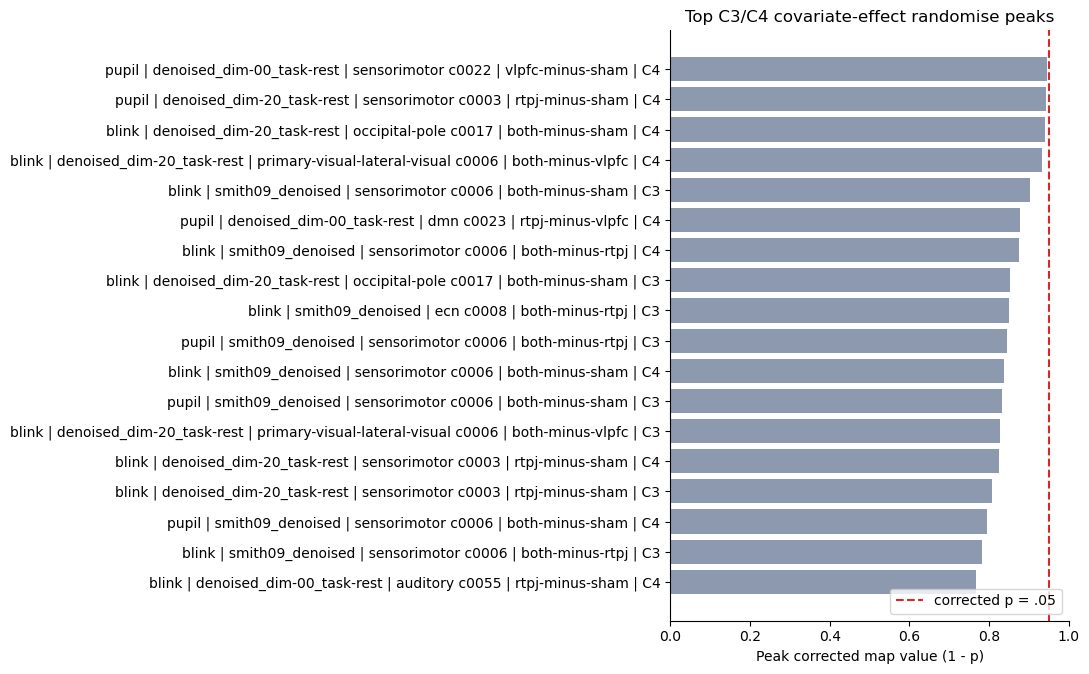

In [3]:
top_n = min(18, len(covariate_rows))
top = covariate_rows.sort_values('peak_corrp_num', ascending=False).head(top_n).iloc[::-1].copy()
labels = (
    top['model_label'].str.replace('cov-fdmean-', '', regex=False)
    + ' | ' + top['analysis']
    + ' | ' + top['network']
    + ' c' + top['component']
    + ' | ' + top['condition_contrast']
    + ' | ' + top['design_contrast']
)
colors = np.where(top['peak_corrp_num'] > CORRP_THRESHOLD, '#0072B2', '#8d99ae')

fig_height = max(5, 0.38 * top_n)
fig, ax = plt.subplots(figsize=(11, fig_height))
ax.barh(labels, top['peak_corrp_num'], color=colors)
ax.axvline(CORRP_THRESHOLD, color='#d62828', linestyle='--', linewidth=1.5, label='corrected p = .05')
ax.set_xlim(0, 1)
ax.set_xlabel('Peak corrected map value (1 - p)')
ax.set_title('Top C3/C4 covariate-effect randomise peaks')
ax.legend(loc='lower right')
for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

## 4. C3/C4 scatterplots

Scatterplots use tracked `*_subjectContrast_values.tsv` files. For each significant C3/C4 map, the x axis is the blink or pupil contrast delta and the y axis is the subject-level brain contrast beta extracted from the corrected map ROI. Mean FD remains in the model but is not plotted on the x axis. If no C3/C4 ROI tables exist, the cell reports that explicitly.

In [4]:
COVARIATE_LABELS = {
    'delta_blink_rate_per_min': 'Blink-rate contrast delta (per min)',
    'delta_mean_pupil_area': 'Mean pupil-area contrast delta',
}

def project_path(value):
    path = Path(value)
    return path if path.is_absolute() else PROJECT_ROOT / path

def describe_row(row):
    model = row['model_label'].replace('cov-fdmean-', '').title()
    return (
        f"{model}: {row['analysis']} {row['network']} comp {row['component']} | "
        f"{row['condition_contrast']} | {row['design_contrast']} {row['contrast_name']}"
    )

def plot_covariate_scatter(row):
    values_path = project_path(row['roi_values_tsv'])
    values = pd.read_csv(values_path, sep='\t', dtype=str, keep_default_na=False)
    x_col = row['tested_covariate']
    y_col = 'subject_contrast_beta'
    if x_col not in values:
        raise KeyError(f'{x_col} missing from {values_path}')
    values[x_col] = pd.to_numeric(values[x_col], errors='coerce')
    values[y_col] = pd.to_numeric(values[y_col], errors='coerce')
    values = values.dropna(subset=[x_col, y_col]).copy()
    if len(values) < 3:
        raise ValueError(f'Not enough complete rows for {values_path}')

    pearson = stats.pearsonr(values[x_col], values[y_col])
    spearman = stats.spearmanr(values[x_col], values[y_col])
    slope, intercept, r_value, p_value, stderr = stats.linregress(values[x_col], values[y_col])
    x_line = np.linspace(values[x_col].min(), values[x_col].max(), 100)
    y_line = intercept + slope * x_line

    fig, ax = plt.subplots(figsize=(6.8, 5.2))
    ax.scatter(values[x_col], values[y_col], s=42, color='#0072B2', alpha=0.82, edgecolor='white', linewidth=0.6)
    ax.plot(x_line, y_line, color='#d62828', linewidth=2)
    ax.axhline(0, color='0.75', linewidth=1)
    ax.axvline(0, color='0.75', linewidth=1)
    ax.set_xlabel(COVARIATE_LABELS.get(x_col, x_col))
    ax.set_ylabel('Brain contrast beta in corrected ROI')
    ax.set_title(describe_row(row), fontsize=10)
    ax.text(
        0.02, 0.98,
        f"n = {len(values)}\nPearson r = {pearson.statistic:.2f}, p = {pearson.pvalue:.3g}\n"
        f"Spearman rho = {spearman.statistic:.2f}, p = {spearman.pvalue:.3g}",
        transform=ax.transAxes,
        va='top',
        ha='left',
        bbox={'boxstyle': 'round,pad=0.3', 'facecolor': 'white', 'edgecolor': '0.82'},
    )
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)
    plt.tight_layout()
    plt.show()
    return values

scatter_rows = covariate_rows[covariate_rows['roi_values_tsv'].str.strip().ne('')].copy()
if scatter_rows.empty:
    display(Markdown(
        '**No C3/C4 scatterplots are currently available.** The covariate randomise compiler only wrote ROI-value TSVs for maps with `1-p > 0.95`, and no C3/C4 maps crossed that corrected threshold in this run.'
    ))
    display(Markdown('Closest C3/C4 peaks are shown below for review.'))
    display(covariate_rows.sort_values('peak_corrp_num', ascending=False).head(12)[audit_columns].style.format({'corrected_p': '{:.4f}'}))
else:
    for _, row in scatter_rows.sort_values('peak_corrp_num', ascending=False).iterrows():
        display(Markdown(f"### {describe_row(row)}"))
        plot_covariate_scatter(row)

**No C3/C4 scatterplots are currently available.** The covariate randomise compiler only wrote ROI-value TSVs for maps with `1-p > 0.95`, and no C3/C4 maps crossed that corrected threshold in this run.

Closest C3/C4 peaks are shown below for review.

,peak_corrp,corrected_p,model_label,analysis,network,component,condition_contrast,design_contrast,contrast_name,tested_covariate,expected_participants,status,roi_values_tsv
51,0.9444,0.0556,cov-fdmean-pupil,denoised_dim-00_task-rest,sensorimotor,0022,vlpfc-minus-sham,C4,cov_neg,delta_mean_pupil_area,25,ok,
63,0.9428,0.0572,cov-fdmean-pupil,denoised_dim-20_task-rest,sensorimotor,0003,rtpj-minus-sham,C4,cov_neg,delta_mean_pupil_area,27,ok,
23,0.9388,0.0612,cov-fdmean-blink,denoised_dim-20_task-rest,occipital-pole,0017,both-minus-sham,C4,cov_neg,delta_blink_rate_per_min,27,ok,
19,0.9332,0.0668,cov-fdmean-blink,denoised_dim-20_task-rest,primary-visual-lateral-visual,0006,both-minus-vlpfc,C4,cov_neg,delta_blink_rate_per_min,27,ok,
38,0.9024,0.0976,cov-fdmean-blink,smith09_denoised,sensorimotor,0006,both-minus-sham,C3,cov_pos,delta_blink_rate_per_min,27,ok,
55,0.8766,0.1234,cov-fdmean-pupil,denoised_dim-00_task-rest,dmn,0023,rtpj-minus-vlpfc,C4,cov_neg,delta_mean_pupil_area,25,ok,
43,0.8756,0.1244,cov-fdmean-blink,smith09_denoised,sensorimotor,0006,both-minus-rtpj,C4,cov_neg,delta_blink_rate_per_min,27,ok,
22,0.8514,0.1486,cov-fdmean-blink,denoised_dim-20_task-rest,occipital-pole,0017,both-minus-sham,C3,cov_pos,delta_blink_rate_per_min,27,ok,
46,0.8506,0.1494,cov-fdmean-blink,smith09_denoised,ecn,0008,both-minus-rtpj,C3,cov_pos,delta_blink_rate_per_min,27,ok,
90,0.8452,0.1548,cov-fdmean-pupil,smith09_denoised,sensorimotor,0006,both-minus-rtpj,C3,cov_pos,delta_mean_pupil_area,26,ok,


## 5. C1/C2 main-effect robustness

C1/C2 are the adjusted main-effect tests. This section compares the original 12 significant cluster-extent results against the corresponding covariate-adjusted C1/C2 rows from the blink and pupil models. A result is marked robust when the covariate-adjusted peak still exceeds `1-p > 0.95`.

In [ ]:
ORIGINAL_SUMMARIES = [
    PROJECT_ROOT / 'derivatives' / 'fsl' / 'randomise_summary' / 'task-rest_randomise_peak_summary.tsv',
    PROJECT_ROOT / 'derivatives' / 'fsl' / 'randomise_summary' / 'task-rest_desc-SecondaryNetworks_randomise_peak_summary.tsv',
]

original_tables = []
for path in ORIGINAL_SUMMARIES:
    if path.is_file():
        table = pd.read_csv(path, sep='\t', dtype=str, keep_default_na=False)
        table['source_summary'] = path.name
        original_tables.append(table)
if not original_tables:
    raise FileNotFoundError('No original randomise summary tables were found.')
original = pd.concat(original_tables, ignore_index=True)
original['peak_corrp_num'] = pd.to_numeric(original['peak_corrp'], errors='coerce')
original['corrected_p'] = 1.0 - original['peak_corrp_num']

original_sig = original[
    original['inference'].eq('cluster-extent')
    & original['status'].eq('ok')
    & original['peak_gt_threshold'].eq('true')
    & original['design_contrast'].isin(['C1', 'C2'])
].copy()

def analysis_key(value):
    value = str(value)
    if value in {'0', '20', 'smith09'}:
        return value
    if 'dim-00' in value:
        return '0'
    if 'dim-20' in value:
        return '20'
    if 'smith09' in value:
        return 'smith09'
    return value

def component_key(value):
    return str(int(value))

for table in (original_sig, summary):
    table['analysis_key'] = table['analysis'].map(analysis_key)
    table['component_key'] = table['component'].map(component_key)
    table['main_key'] = list(zip(
        table['analysis_key'], table['network'], table['component_key'],
        table['condition_contrast'], table['design_contrast']
    ))

main_rows = summary[
    summary['design_contrast'].isin(['C1', 'C2'])
    & summary['inference'].eq('cluster-extent')
].copy()
main_rows['peak_corrp_num'] = pd.to_numeric(main_rows['peak_corrp'], errors='coerce')
main_rows['corrected_p'] = 1.0 - main_rows['peak_corrp_num']
main_rows['analysis_key'] = main_rows['analysis'].map(analysis_key)
main_rows['component_key'] = main_rows['component'].map(component_key)
main_rows['main_key'] = list(zip(
    main_rows['analysis_key'], main_rows['network'], main_rows['component_key'],
    main_rows['condition_contrast'], main_rows['design_contrast']
))

covariate_lookup = {
    (row['main_key'], row['model_label']): row
    for _, row in main_rows.iterrows()
}

records = []
for _, original_row in original_sig.sort_values('peak_corrp_num', ascending=False).iterrows():
    key = original_row['main_key']
    blink = covariate_lookup.get((key, 'cov-fdmean-blink'))
    pupil = covariate_lookup.get((key, 'cov-fdmean-pupil'))
    record = {
        'analysis': original_row['analysis'],
        'network': original_row['network'],
        'component': original_row['component'],
        'condition_contrast': original_row['condition_contrast'],
        'design_contrast': original_row['design_contrast'],
        'direction': original_row['direction'],
        'original_peak': original_row['peak_corrp_num'],
        'original_p': original_row['corrected_p'],
        'blink_peak': np.nan if blink is None else blink['peak_corrp_num'],
        'blink_p': np.nan if blink is None else blink['corrected_p'],
        'blink_n': '' if blink is None else blink['expected_participants'],
        'blink_robust': False if blink is None else bool(blink['peak_corrp_num'] > CORRP_THRESHOLD),
        'pupil_peak': np.nan if pupil is None else pupil['peak_corrp_num'],
        'pupil_p': np.nan if pupil is None else pupil['corrected_p'],
        'pupil_n': '' if pupil is None else pupil['expected_participants'],
        'pupil_robust': False if pupil is None else bool(pupil['peak_corrp_num'] > CORRP_THRESHOLD),
        'main_key': key,
    }
    record['robust_both_models'] = record['blink_robust'] and record['pupil_robust']
    records.append(record)

robustness = pd.DataFrame.from_records(records)
summary_counts = {
    'original_significant': len(robustness),
    'robust_with_fd_blink': int(robustness['blink_robust'].sum()),
    'robust_with_fd_pupil': int(robustness['pupil_robust'].sum()),
    'robust_in_both_covariate_models': int(robustness['robust_both_models'].sum()),
}
display(Markdown(
    f"Original significant C1/C2 rows: **{summary_counts['original_significant']}**. "
    f"Robust with FD+blink: **{summary_counts['robust_with_fd_blink']}**; "
    f"robust with FD+pupil: **{summary_counts['robust_with_fd_pupil']}**; "
    f"robust in both: **{summary_counts['robust_in_both_covariate_models']}**."
))

robust_columns = [
    'analysis', 'network', 'component', 'condition_contrast', 'design_contrast',
    'original_peak', 'original_p', 'blink_peak', 'blink_p', 'blink_n', 'blink_robust',
    'pupil_peak', 'pupil_p', 'pupil_n', 'pupil_robust', 'robust_both_models'
]
display(
    robustness[robust_columns]
    .style.format({
        'original_peak': '{:.4f}', 'original_p': '{:.4f}',
        'blink_peak': '{:.4f}', 'blink_p': '{:.4f}',
        'pupil_peak': '{:.4f}', 'pupil_p': '{:.4f}',
    }, na_rep='')
)

plot_rows = robustness.copy().reset_index(drop=True)
labels = (
    plot_rows['analysis'].astype(str)
    + ' | ' + plot_rows['network'].astype(str)
    + ' c' + plot_rows['component'].astype(str)
    + ' | ' + plot_rows['condition_contrast'].astype(str)
    + ' | ' + plot_rows['design_contrast'].astype(str)
)
y = np.arange(len(plot_rows))
fig, ax = plt.subplots(figsize=(11.5, max(5.5, 0.45 * len(plot_rows))))
ax.scatter(plot_rows['original_peak'], y, label='original', color='#111111', s=44)
ax.scatter(plot_rows['blink_peak'], y + 0.13, label='FD + blink', color='#0072B2', s=44)
ax.scatter(plot_rows['pupil_peak'], y - 0.13, label='FD + pupil', color='#D55E00', s=44)
ax.axvline(CORRP_THRESHOLD, color='#d62828', linestyle='--', linewidth=1.4)
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlim(0.75, 1.005)
ax.set_xlabel('Peak corrected map value (1 - p)')
ax.set_title('Original significant C1/C2 results after covariate adjustment')
ax.legend(loc='lower right')
for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()


## 6. Descriptive C1/C2 covariate scatterplots

These scatterplots are descriptive checks for the adjusted main-effect ROIs. The y axis is the subject-level brain contrast beta in a significant C1/C2 corrected ROI. The x axis is the raw blink or pupil contrast delta from that model. The inferential test for a covariate effect remains C3/C4; these plots ask whether robust main-effect ROIs appear visually tied to the covariate values.

In [ ]:
MODEL_X = {
    'cov-fdmean-blink': 'delta_blink_rate_per_min',
    'cov-fdmean-pupil': 'delta_mean_pupil_area',
}

robust_keys = set(robustness['main_key'])
main_scatter_rows = main_rows[
    main_rows['main_key'].isin(robust_keys)
    & main_rows['roi_values_tsv'].str.strip().ne('')
].copy()

if main_scatter_rows.empty:
    display(Markdown('No C1/C2 ROI-value TSVs are available for the original significant rows.'))
else:
    display(Markdown(f'Found **{len(main_scatter_rows)}** covariate-adjusted C1/C2 ROI tables linked to the original significant set.'))
    display(main_scatter_rows[[
        'model_label', 'analysis', 'network', 'component', 'condition_contrast',
        'design_contrast', 'contrast_name', 'peak_corrp', 'expected_participants', 'roi_values_tsv'
    ]].sort_values('peak_corrp', ascending=False))

def plot_main_effect_scatter(row):
    values_path = project_path(row['roi_values_tsv'])
    values = pd.read_csv(values_path, sep='\t', dtype=str, keep_default_na=False)
    x_col = MODEL_X[row['model_label']]
    y_col = 'subject_contrast_beta'
    values[x_col] = pd.to_numeric(values[x_col], errors='coerce')
    values[y_col] = pd.to_numeric(values[y_col], errors='coerce')
    values = values.dropna(subset=[x_col, y_col]).copy()
    if len(values) < 3:
        raise ValueError(f'Not enough complete rows for {values_path}')

    pearson = stats.pearsonr(values[x_col], values[y_col])
    spearman = stats.spearmanr(values[x_col], values[y_col])
    slope, intercept, r_value, p_value, stderr = stats.linregress(values[x_col], values[y_col])
    x_line = np.linspace(values[x_col].min(), values[x_col].max(), 100)
    y_line = intercept + slope * x_line

    fig, ax = plt.subplots(figsize=(6.8, 5.2))
    ax.scatter(values[x_col], values[y_col], s=42, color='#0072B2', alpha=0.82, edgecolor='white', linewidth=0.6)
    ax.plot(x_line, y_line, color='#d62828', linewidth=2)
    ax.axhline(0, color='0.75', linewidth=1)
    ax.axvline(0, color='0.75', linewidth=1)
    ax.set_xlabel(COVARIATE_LABELS.get(x_col, x_col))
    ax.set_ylabel('Brain contrast beta in adjusted main-effect ROI')
    ax.set_title(describe_row(row), fontsize=10)
    ax.text(
        0.02, 0.98,
        f"n = {len(values)}\nPearson r = {pearson.statistic:.2f}, p = {pearson.pvalue:.3g}\n"
        f"Spearman rho = {spearman.statistic:.2f}, p = {spearman.pvalue:.3g}",
        transform=ax.transAxes,
        va='top',
        ha='left',
        bbox={'boxstyle': 'round,pad=0.3', 'facecolor': 'white', 'edgecolor': '0.82'},
    )
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)
    plt.tight_layout()
    plt.show()

for _, row in main_scatter_rows.sort_values('peak_corrp_num', ascending=False).iterrows():
    display(Markdown(f"### {describe_row(row)}"))
    plot_main_effect_scatter(row)


## 7. Covariate model integrity checks

The peak summary confirms that all randomise outputs completed, but the deeper assumptions require the Linux-side model folders. Run `python3 code/check_covariate_model_integrity.py --fail-on-error` on the Linux box and commit the resulting integrity TSV. This section will then report mask size, demeaning, design/audit agreement, subject order, image-list order, and C3/C4 contrast-vector checks.

In [ ]:
integrity_path = PROJECT_ROOT / 'derivatives' / 'fsl' / 'covariate_randomise_summary' / 'task-rest_covariate-randomise_integrity.tsv'

summary_check_rows = []
for label, series in {
    'all status ok': summary['status'].eq('ok'),
    'all design.con valid': summary['design_con_valid'].eq('true'),
    'all group inputs complete': summary['group_input_complete'].eq('true'),
    'all completion markers present': summary['completion_marker_exists'].eq('true'),
    'all t-stat files present': summary['tstat_exists'].eq('true'),
    'all corrp files present': summary['corrp_exists'].eq('true'),
}.items():
    summary_check_rows.append({'check': label, 'passed': bool(series.all()), 'n_passed': int(series.sum()), 'n_total': len(series)})
display(pd.DataFrame(summary_check_rows))

if integrity_path.is_file():
    integrity = pd.read_csv(integrity_path, sep='\t', dtype=str, keep_default_na=False)
    bool_columns = [
        'group_input_complete', 'mask_exists', 'design_con_valid', 'intercept_all_ones',
        'covariate_columns_demeaned', 'design_matches_covariate_audit',
        'subject_order_matches_audit', 'image_list_matches_audit', 'c3_c4_test_last_covariate', 'complete'
    ]
    integrity_summary = []
    for column in bool_columns:
        passed = integrity[column].eq('true')
        integrity_summary.append({'check': column, 'n_passed': int(passed.sum()), 'n_total': len(integrity), 'all_passed': bool(passed.all())})
    display(Markdown(f'Loaded integrity audit with **{len(integrity)}** rows.'))
    display(pd.DataFrame(integrity_summary))
    if 'mask_voxels' in integrity:
        mask_values = pd.to_numeric(integrity['mask_voxels'], errors='coerce').dropna()
        if len(mask_values):
            display(Markdown(f'Mask voxel range: **{int(mask_values.min())} - {int(mask_values.max())}**.'))
    problems = integrity[integrity['complete'].ne('true')]
    if problems.empty:
        display(Markdown('All covariate model integrity checks passed.'))
    else:
        display(Markdown('Integrity rows needing review:'))
        display(problems)
else:
    display(Markdown(
        'No tracked integrity TSV found yet. On Linux, run:\n\n'
        '`python3 code/check_covariate_model_integrity.py --fail-on-error`\n\n'
        'Then commit `derivatives/fsl/covariate_randomise_summary/task-rest_covariate-randomise_integrity.tsv`.'
    ))
